## 1- load & explore datasets

Load datasets:

In [1]:
import pandas as pd

habits = pd.read_csv('data/raw/enhanced_student_habits_performance_dataset.csv')
mental= pd.read_csv('data/raw/student_mental_health_burnout.csv')

print(habits.shape)
print(mental.shape)
print(habits.columns.tolist())
print(mental.columns.tolist())

print(habits.isnull().sum())  # count missing values

(80000, 31)
(150000, 20)
['student_id', 'age', 'gender', 'major', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'previous_gpa', 'semester', 'stress_level', 'dropout_risk', 'social_activity', 'screen_time', 'study_environment', 'access_to_tutoring', 'family_income_range', 'parental_support_level', 'motivation_level', 'exam_anxiety_score', 'learning_style', 'time_management_score', 'exam_score']
['student_id', 'age', 'gender', 'course', 'year', 'daily_study_hours', 'daily_sleep_hours', 'screen_time_hours', 'stress_level', 'anxiety_score', 'depression_score', 'academic_pressure_score', 'financial_stress_score', 'social_support_score', 'physical_activity_hours', 'sleep_quality', 'attendance_percentage', 'cgpa', 'internet_quality', 'burnout_level']
student_id                    

`.isnull()` → returns a DataFrame of True/False — True wherever a value is missing  
`.sum()` → counts the Trues per column (True = 1, False = 0)  
Output: each column with how many missing values it has  
Why: missing values break your model — you need to know where  
they are before cleaning  

Explore distributions:

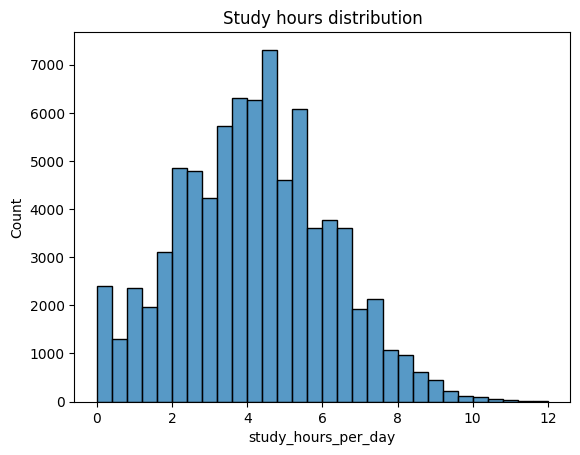

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of study hours
sns.histplot(habits['study_hours_per_day'], bins=30)
plt.title('Study hours distribution')
plt.show()

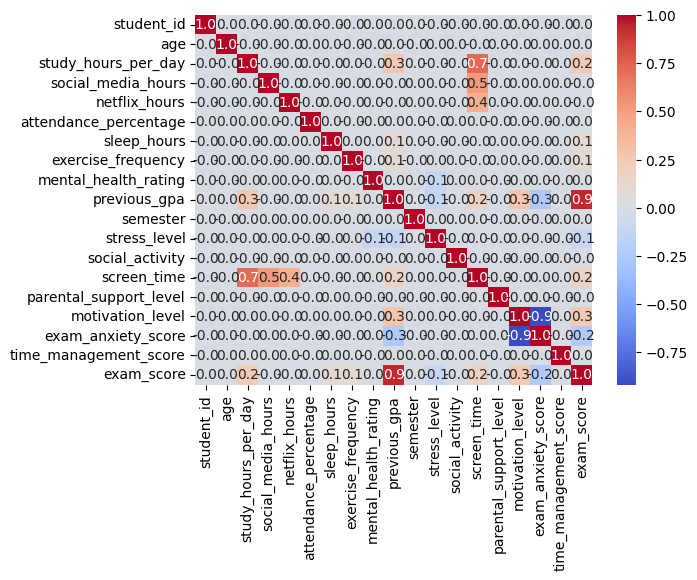

In [3]:
# Correlation heatmap
numeric = habits.select_dtypes(include='number')
sns.heatmap(numeric.corr(), annot=True, fmt='.1f', cmap='coolwarm')
plt.show()

## 2-cleaning and merging

Handling missing values:

In [4]:
# Drop rows with too many nulls
habits.dropna(thresh=len(habits.columns)*0.7, inplace=False)

# Fill numeric nulls with median(If a numeric column has missing values, those missing values will be replaced by the median of that column.)
num_cols = habits.select_dtypes(include='number').columns
habits[num_cols] = habits[num_cols].fillna(habits[num_cols].median())

# Fill categorical Nulls with mode(If a categorical column has missing values, those missing values will be replaced by the most frequent value in that column.)
cat_cols = habits.select_dtypes(include='object').columns
for col in cat_cols:
    habits[col].fillna(habits[col].mode()[0])

Merge the two datasets:

In [5]:
# Merge on student_id (inner join = only students in both)
df = pd.merge(habits, mental, on='student_id', how='inner')

# If column names clash, pandas adds _x and _y suffixes
# Rename or drop duplicates manually:
# df.drop(columns=['age_y'], inplace=True)
# df.rename(columns={'age_x': 'age'}, inplace=True)

print(df.shape)
print(df.columns.tolist())
# Get the data types of each column
print(df.dtypes)

(79999, 50)
['student_id', 'age_x', 'gender_x', 'major', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage_x', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality_x', 'mental_health_rating', 'extracurricular_participation', 'previous_gpa', 'semester', 'stress_level_x', 'dropout_risk', 'social_activity', 'screen_time', 'study_environment', 'access_to_tutoring', 'family_income_range', 'parental_support_level', 'motivation_level', 'exam_anxiety_score', 'learning_style', 'time_management_score', 'exam_score', 'age_y', 'gender_y', 'course', 'year', 'daily_study_hours', 'daily_sleep_hours', 'screen_time_hours', 'stress_level_y', 'anxiety_score', 'depression_score', 'academic_pressure_score', 'financial_stress_score', 'social_support_score', 'physical_activity_hours', 'sleep_quality', 'attendance_percentage_y', 'cgpa', 'internet_quality_y', 'burnout_level']
student_id                         int

In [6]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(cat_cols)

['gender_x', 'major', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality_x', 'extracurricular_participation', 'dropout_risk', 'study_environment', 'access_to_tutoring', 'family_income_range', 'learning_style', 'gender_y', 'course', 'year', 'stress_level_y', 'sleep_quality', 'internet_quality_y', 'burnout_level']


In [7]:
# Check exact column names[list comprehension]
print([col for col in df.columns if 'attendance' in col])
print([col for col in df.columns if 'stress' in col])
print([col for col in df.columns if 'burnout' in col])
print([col for col in df.columns if 'motivation' in col])
print([col for col in df.columns if 'social_activity' in col])
print([col for col in df.columns if 'parental_support' in col])

['attendance_percentage_x', 'attendance_percentage_y']
['stress_level_x', 'stress_level_y', 'financial_stress_score']
['burnout_level']
['motivation_level']
['social_activity']
['parental_support_level']


In [9]:
# Keep _x versions (from habits dataset), drop _y versions
df.rename(columns={
    'attendance_percentage_x': 'attendance_percentage',
    'stress_level_x': 'stress_level',
}, inplace=True)

# Drop the _y duplicates — same info, not needed
df.drop(columns=[
    'attendance_percentage_y',
    'stress_level_y',
], inplace=True)

print("Done! Clean columns:")
print(df.columns.tolist())

Done! Clean columns:
['student_id', 'age_x', 'gender_x', 'major', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality_x', 'mental_health_rating', 'extracurricular_participation', 'previous_gpa', 'semester', 'stress_level', 'dropout_risk', 'social_activity', 'screen_time', 'study_environment', 'access_to_tutoring', 'family_income_range', 'parental_support_level', 'motivation_level', 'exam_anxiety_score', 'learning_style', 'time_management_score', 'exam_score', 'age_y', 'gender_y', 'course', 'year', 'daily_study_hours', 'daily_sleep_hours', 'screen_time_hours', 'anxiety_score', 'depression_score', 'academic_pressure_score', 'financial_stress_score', 'social_support_score', 'physical_activity_hours', 'sleep_quality', 'cgpa', 'internet_quality_y', 'burnout_level']


In [ ]:
# Drop remaining duplicates
df.drop(columns=[
    'age_y',
    'gender_y',
    'gender_y_enc',
    'internet_quality_y',
    'internet_quality_y_enc',
    'course',      # same as major
    'course_enc',
    'year',        # same as semester
    'year_enc',
], inplace=True)

# Rename remaining _x columns
df.rename(columns={
    'age_x': 'age',
    'gender_x': 'gender',
    'gender_x_enc': 'gender_enc',
    'internet_quality_x': 'internet_quality',
    'internet_quality_x_enc': 'internet_quality_enc',
}, inplace=True)

print("Final columns:")
print(df.columns.tolist())

Final columns:
['student_id', 'age', 'gender', 'major', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'previous_gpa', 'semester', 'stress_level', 'dropout_risk', 'social_activity', 'screen_time', 'study_environment', 'access_to_tutoring', 'family_income_range', 'parental_support_level', 'motivation_level', 'exam_anxiety_score', 'learning_style', 'time_management_score', 'exam_score', 'daily_study_hours', 'daily_sleep_hours', 'screen_time_hours', 'anxiety_score', 'depression_score', 'academic_pressure_score', 'financial_stress_score', 'social_support_score', 'physical_activity_hours', 'sleep_quality', 'cgpa', 'burnout_level', 'gender_enc', 'major_enc', 'part_time_job_enc', 'diet_quality_enc', 'parental_education_level_enc', 'internet_quality_enc', 'extracurricular_participat

Encode & scale:

In [11]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pickle, os

# Step 1 — encode first
le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
print("Encoding done!")

# Step 2 — define features (now _enc columns exist)
features = [
    'study_hours_per_day', 'daily_study_hours', 'attendance_percentage',
    'time_management_score', 'motivation_level', 'sleep_hours',
    'daily_sleep_hours', 'exercise_frequency', 'physical_activity_hours',
    'diet_quality_enc', 'sleep_quality_enc', 'mental_health_rating',
    'stress_level', 'anxiety_score', 'depression_score', 'exam_anxiety_score',
    'burnout_level_enc', 'academic_pressure_score', 'social_media_hours',
    'netflix_hours', 'screen_time', 'social_activity',
    'financial_stress_score', 'social_support_score', 'parental_support_level',
]

missing = [f for f in features if f not in df.columns]
print("Missing:", missing)

# Step 3 — scale
X = df[features].copy()
X = X.fillna(X.median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

os.makedirs('models', exist_ok=True)
pickle.dump(scaler, open('models/scaler.pkl', 'wb'))
print("X_scaled shape:", X_scaled.shape)
print("Ready for clustering!")


Encoding done!
Missing: []
X_scaled shape: (79999, 25)
Ready for clustering!


### NB : why are we doing this ??  
  
`Loading the data`  
Obviously — you can't cook without ingredients.  
  
`Merging the two datasets`  
You had habits data in one file and mental health data in another. Same students, split across two files. You merged them so each student has ALL their information in one row — habits + mental health together. That's the whole point of using two datasets.  

`Renaming and dropping _x _y columns`  
Merging created duplicates with ugly names. You cleaned them up so your dataframe is readable and has no redundant information confusing the model.  
  
`LabelEncoder`  
K-Means is pure math — it calculates distances between points. It cannot do math on words like "high", "medium", "low" or "male", "female". So you converted every text column to numbers. **burnout_level** had "low/medium/high" → now **burnout_level_enc** has 0/1/2.  
  
`Choosing features`  
Not all 50 columns are useful for clustering. You want only the columns that describe student behavior and wellbeing — the things that actually define what type of student someone is. You excluded outcomes like **exam_score** and **cgpa** because those are results, not behaviors.  
  
Two messy CSV files  
        ↓  
Merge → one table, all students  
        ↓  
Clean duplicates → no _x _y mess  
        ↓  
Encode text → no words, only numbers  
        ↓  
Select features → only behavior columns  
        ↓  
Verify → nothing missing  
        ↓  
Scale → fair competition between features  
        ↓  
K-Means → finally find the clusters  

In [ ]:
print(df['burnout_level_enc'].tolist())

[0, 1, 0, 0, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 2, 0, 2, 2, 2, 2, 2, 0, 1, 1, 1, 0, 1, 1, 2, 2, 1, 1, 0, 1, 1, 1, 1, 2, 1, 1, 0, 2, 0, 0, 1, 1, 0, 0, 2, 0, 1, 0, 2, 1, 2, 0, 1, 2, 2, 0, 1, 0, 1, 2, 2, 0, 2, 1, 2, 2, 2, 2, 0, 1, 1, 1, 2, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 2, 0, 1, 1, 1, 1, 2, 2, 1, 0, 0, 2, 2, 1, 0, 0, 0, 2, 1, 2, 2, 1, 2, 2, 2, 0, 0, 1, 1, 2, 1, 2, 2, 1, 0, 1, 1, 1, 2, 2, 2, 1, 2, 2, 1, 1, 2, 1, 1, 0, 0, 0, 2, 0, 1, 2, 0, 2, 1, 2, 1, 0, 2, 2, 1, 2, 1, 0, 0, 1, 2, 0, 1, 1, 0, 2, 0, 1, 1, 1, 0, 2, 1, 1, 1, 1, 2, 2, 0, 0, 1, 0, 0, 1, 1, 2, 1, 2, 1, 1, 1, 0, 0, 0, 0, 0, 2, 0, 2, 1, 2, 2, 1, 2, 1, 0, 2, 0, 0, 2, 0, 1, 0, 0, 1, 0, 0, 0, 0, 2, 0, 1, 0, 1, 1, 2, 0, 0, 2, 2, 0, 1, 2, 2, 2, 0, 0, 2, 0, 2, 0, 2, 2, 2, 1, 2, 0, 2, 2, 1, 0, 2, 1, 1, 0, 0, 1, 0, 0, 1, 1, 2, 0, 2, 1, 1, 0, 0, 1, 2, 1, 0, 1, 1, 0, 1, 2, 0, 0, 2, 2, 2, 2, 0, 1, 0, 1, 2, 0, 2, 2, 2, 1, 0, 1, 1, 2, 0, 1, 2, 2, 1, 1, 2, 0, 1, 0, 2, 1, 2, 0, 2, 0, 0, 0, 0, 0, 2, 1, 1, 1, 2, 0, 1, 2, 0, 1, 0, 2, 2, 2, 0, 

## 3-Clustering 

Find the best K for k-means (elbow method to determine the optimal number of clusters (K))

Inertia and silhouette score are two such metrics that help us determine the optimal number of clusters (K) for K-Means clustering.

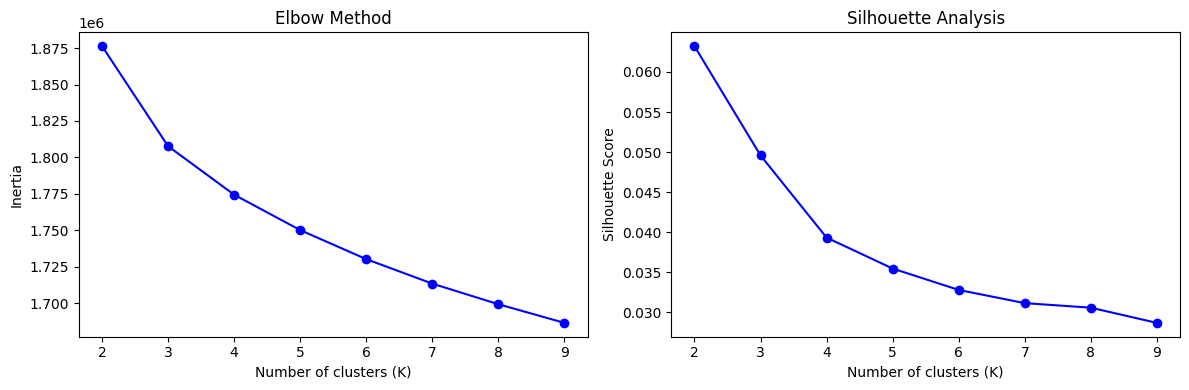

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouettes = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Plot Elbow Method
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouettes, 'bo-')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')

plt.tight_layout()
plt.show()

In [ ]:
print(X_scaled.shape)

(79999, 25)


Train final model:


In [14]:
BEST_K = 4  # based on elbow plot

kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Save model
pickle.dump(kmeans, open('models/kmeans.pkl', 'wb'))
print("Model saved!")

Model saved!


Purpose: Saving the model allows you to reuse it later without having to retrain it. This is particularly useful if you want to apply the model to new data or deploy it in a production environment.

Name clusters:

In [19]:
# Analyze each cluster's average profile
profile = df.groupby('cluster')[features].mean()
print(profile.round(2))

# After reading the output, define names manually:
cluster_names = {
    0: "High-Screen-Time Relaxed Students",
    1: "Moderate-Study Low-Stress Students",
    2: "High-Anxiety Low-Motivation Students",
    3: "High-Screen-Time Burned-Out Students"
}
df['cluster_name'] = df['cluster'].map(cluster_names)

         study_hours_per_day  daily_study_hours  attendance_percentage  \
cluster                                                                  
0                       5.35               5.43                  69.66   
1                       3.05               5.56                  70.33   
2                       3.05               5.51                  69.63   
3                       5.33               5.51                  70.27   

         time_management_score  motivation_level  sleep_hours  \
cluster                                                         
0                         5.52              8.49         7.02   
1                         5.50              8.49         7.01   
2                         5.46              3.50         7.02   
3                         5.53              3.51         7.02   

         daily_sleep_hours  exercise_frequency  physical_activity_hours  \
cluster                                                                   
0             

PCA:Reduce the dimensionality (number of features) of a dataset while preserving as much variability (information) as possible.

In [25]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


PCA scatter plot:

You have 25 features — that means each student lives in a 25-dimensional space. You can't visualize 25 dimensions. PCA compresses those 25 dimensions down to 2 while keeping as much information as possible, so you can plot every student as a dot on a 2D chart.
25 features → PCA → 2 numbers (pca_x, pca_y) → plot as X,Y on a scatter

In [28]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import plotly.express as px

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
df['pca_x'] = coords[:,0]
df['pca_y'] = coords[:,1]

fig = px.scatter(df, x='pca_x', y='pca_y',
                color='cluster_name',
                hover_data=[
                    'study_hours_per_day', 'attendance_percentage', 'time_management_score',
                    'sleep_hours', 'exercise_frequency',
                    'stress_level', 'anxiety_score', 'mental_health_rating',
                    'social_media_hours', 'social_activity',
                    'social_support_score', 'parental_support_level'
                ],
                title='Student Segments (PCA projection)',
                template='plotly_white')
fig.show()  # interactive! hover over dots

ModuleNotFoundError: No module named 'plotly'